Question 1a

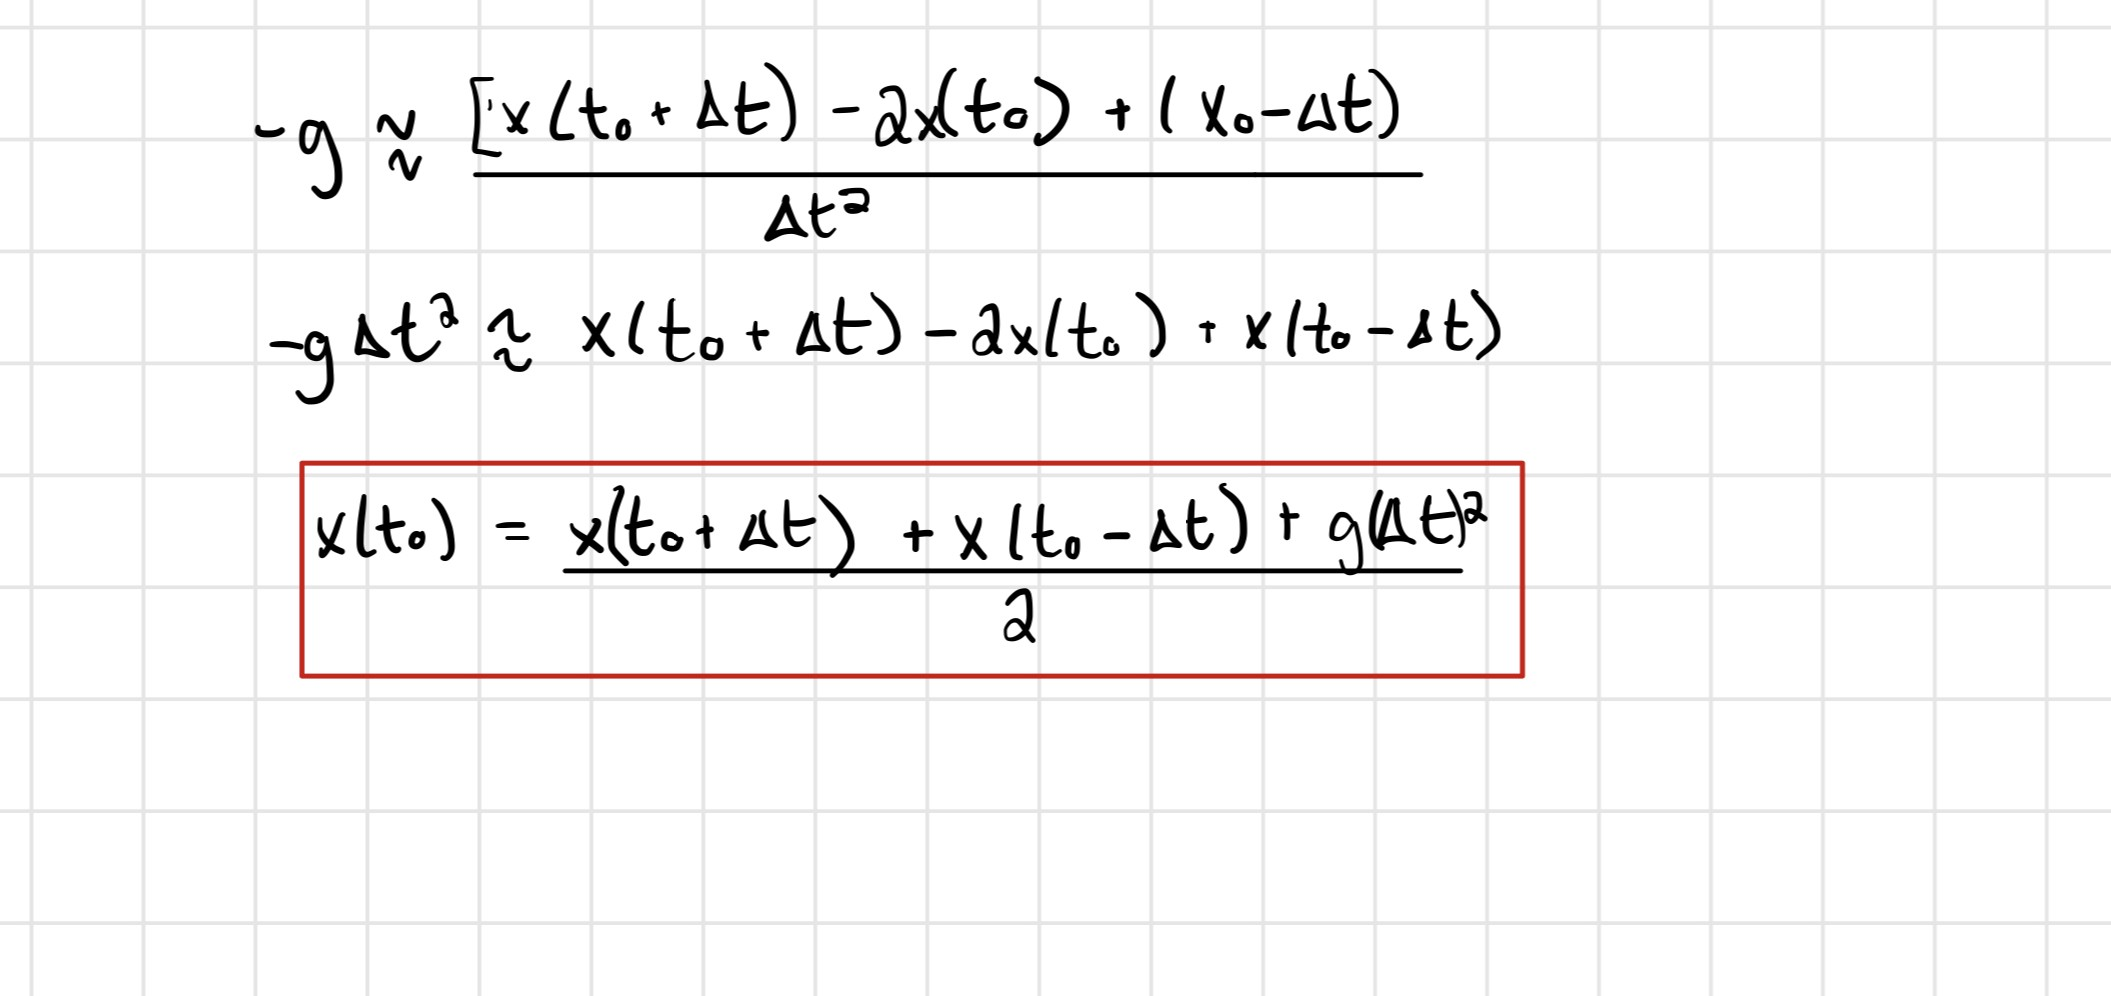

Question 1b

In [53]:
import numpy as np
import math as m
import matplotlib.pyplot as plt

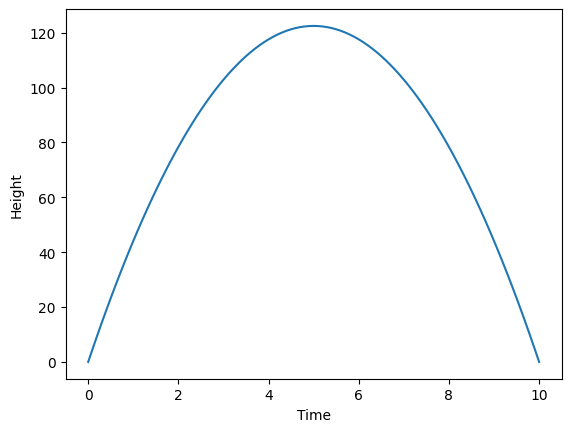

In [54]:
#initial conditions
x0 = 0
t0 = 0
tf = 10
m = 1
pts = 100
acc = 1e-6
g = 9.8
    
#function for relaxation method
def relax():
    #set up variables
    dt = tf/pts
    t = np.linspace(t0, tf, pts+1)
    x = np.ones(pts+1)

    x[0] = 0
    x[pts] = 0

    max_iters = 10000

    for iteration in range(max_iters):
        max_change = 0

        for i in range(1, pts):
            #perform relaxation step
            x_new = 0.5*(x[i+1] + x[i-1] + g*dt**2)
            change = abs(x_new - x[i])
            x[i] = x_new

            if change > max_change:
                #set new max change
                max_change = change
        
        if max_change < acc:
            #convergence reached
            break

    return x, t

#plot the result
x, t = relax()
plt.plot(t, x)
plt.xlabel("Time")
plt.ylabel("Height")
plt.show()

Question 2

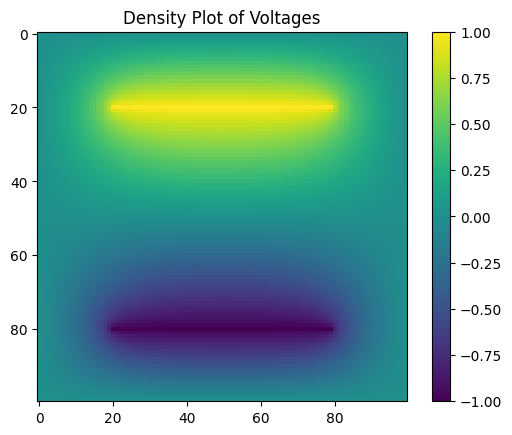

In [55]:
#grid setup
N = 100
arr = np.zeros((N, N))

#define plate positions
left_plate_x = 20
plate_y_start = 20
right_plate_x = 80
plate_y_end = 80

#set fixed potentials for the plates
arr[left_plate_x, plate_y_start:plate_y_end] = 1.0
arr[right_plate_x, plate_y_start:plate_y_end] = -1.0

#fixed points mask
fixed = np.zeros((N, N), dtype=bool)

#set boundary edges as fixed
fixed[0, :] = True
fixed[-1, :] = True
fixed[:, 0] = True
fixed[:, -1] = True

#set plates as fixed
fixed[left_plate_x, plate_y_start:plate_y_end] = True
fixed[right_plate_x, plate_y_start: plate_y_end] = True

#relaxation parameters
tol = 1e-6
delta = 1.0

while delta > tol:
    delta = 0.0 #reset max change each iteration

    #loop over interior grid points
    for i in range(1, N-1):
        for j in range(1, N-1):
            #skip fixed points
            if not fixed[i, j]:
                #perform the relaxation step
                newArr = 0.25 * (
                    arr[i+1, j] + arr[i-1, j] +
                    arr[i, j+1] + arr[i, j-1]
                )

                #check convergence
                diff = abs(newArr - arr[i, j])
                if diff > delta:
                    delta = diff
                #update grid value
                arr[i, j] = newArr

#plot the result
plt.imshow(arr)
plt.colorbar()
plt.title("Density Plot of Voltages")
plt.show()

Question 3

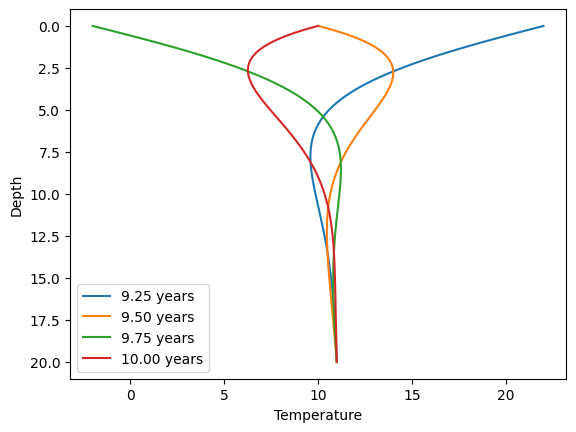

In [56]:
#set up initial conditions
a = 10
b = 12
tau = 365
d = 0.1
dt = 0.01
dx = 0.2

L = 20
N = int(L / dx)
x = np.linspace(0, L, N)

#function to perform FTCS method
def step(T, t):
    #copy the array to avoid modifying
    T_new = T.copy()

    #interior points update
    for i in range(1, len(T)-1):
        #FTCS formula for 1D heat equation
        T_new[i] = T[i] + (d*dt/dx**2) * (T[i+1] + T[i-1] - 2*T[i])

    #set T boundary conditions
    T_new[0] = a + b * np.sin(2*np.pi*t/tau)
    T_new[-1] = 11

    return T_new

#initial temperature profile
T = np.ones(N) * 10
T[-1] = 11

#time evolution setup
years = 10
t_max = tau * years
steps = int(t_max / dt)

#times to be measured at
times = [9.25*365, 9.5*365, 9.75*365, t_max]
stored = []

t = 0
#main time loop
for i in range(steps):
    T = step(T, t)
    t += dt
    #check if current time is close to any target times
    for target in times:
        if abs(t - target) < dt/2:
            stored.append(T.copy())

#plot the result
for profile, time_val in zip(stored, times):
    plt.plot(profile, x, label=f"{time_val/365:.2f} years")
plt.gca().invert_yaxis()
plt.xlabel("Temperature")
plt.ylabel("Depth")
plt.legend()
plt.show()

Question 4a

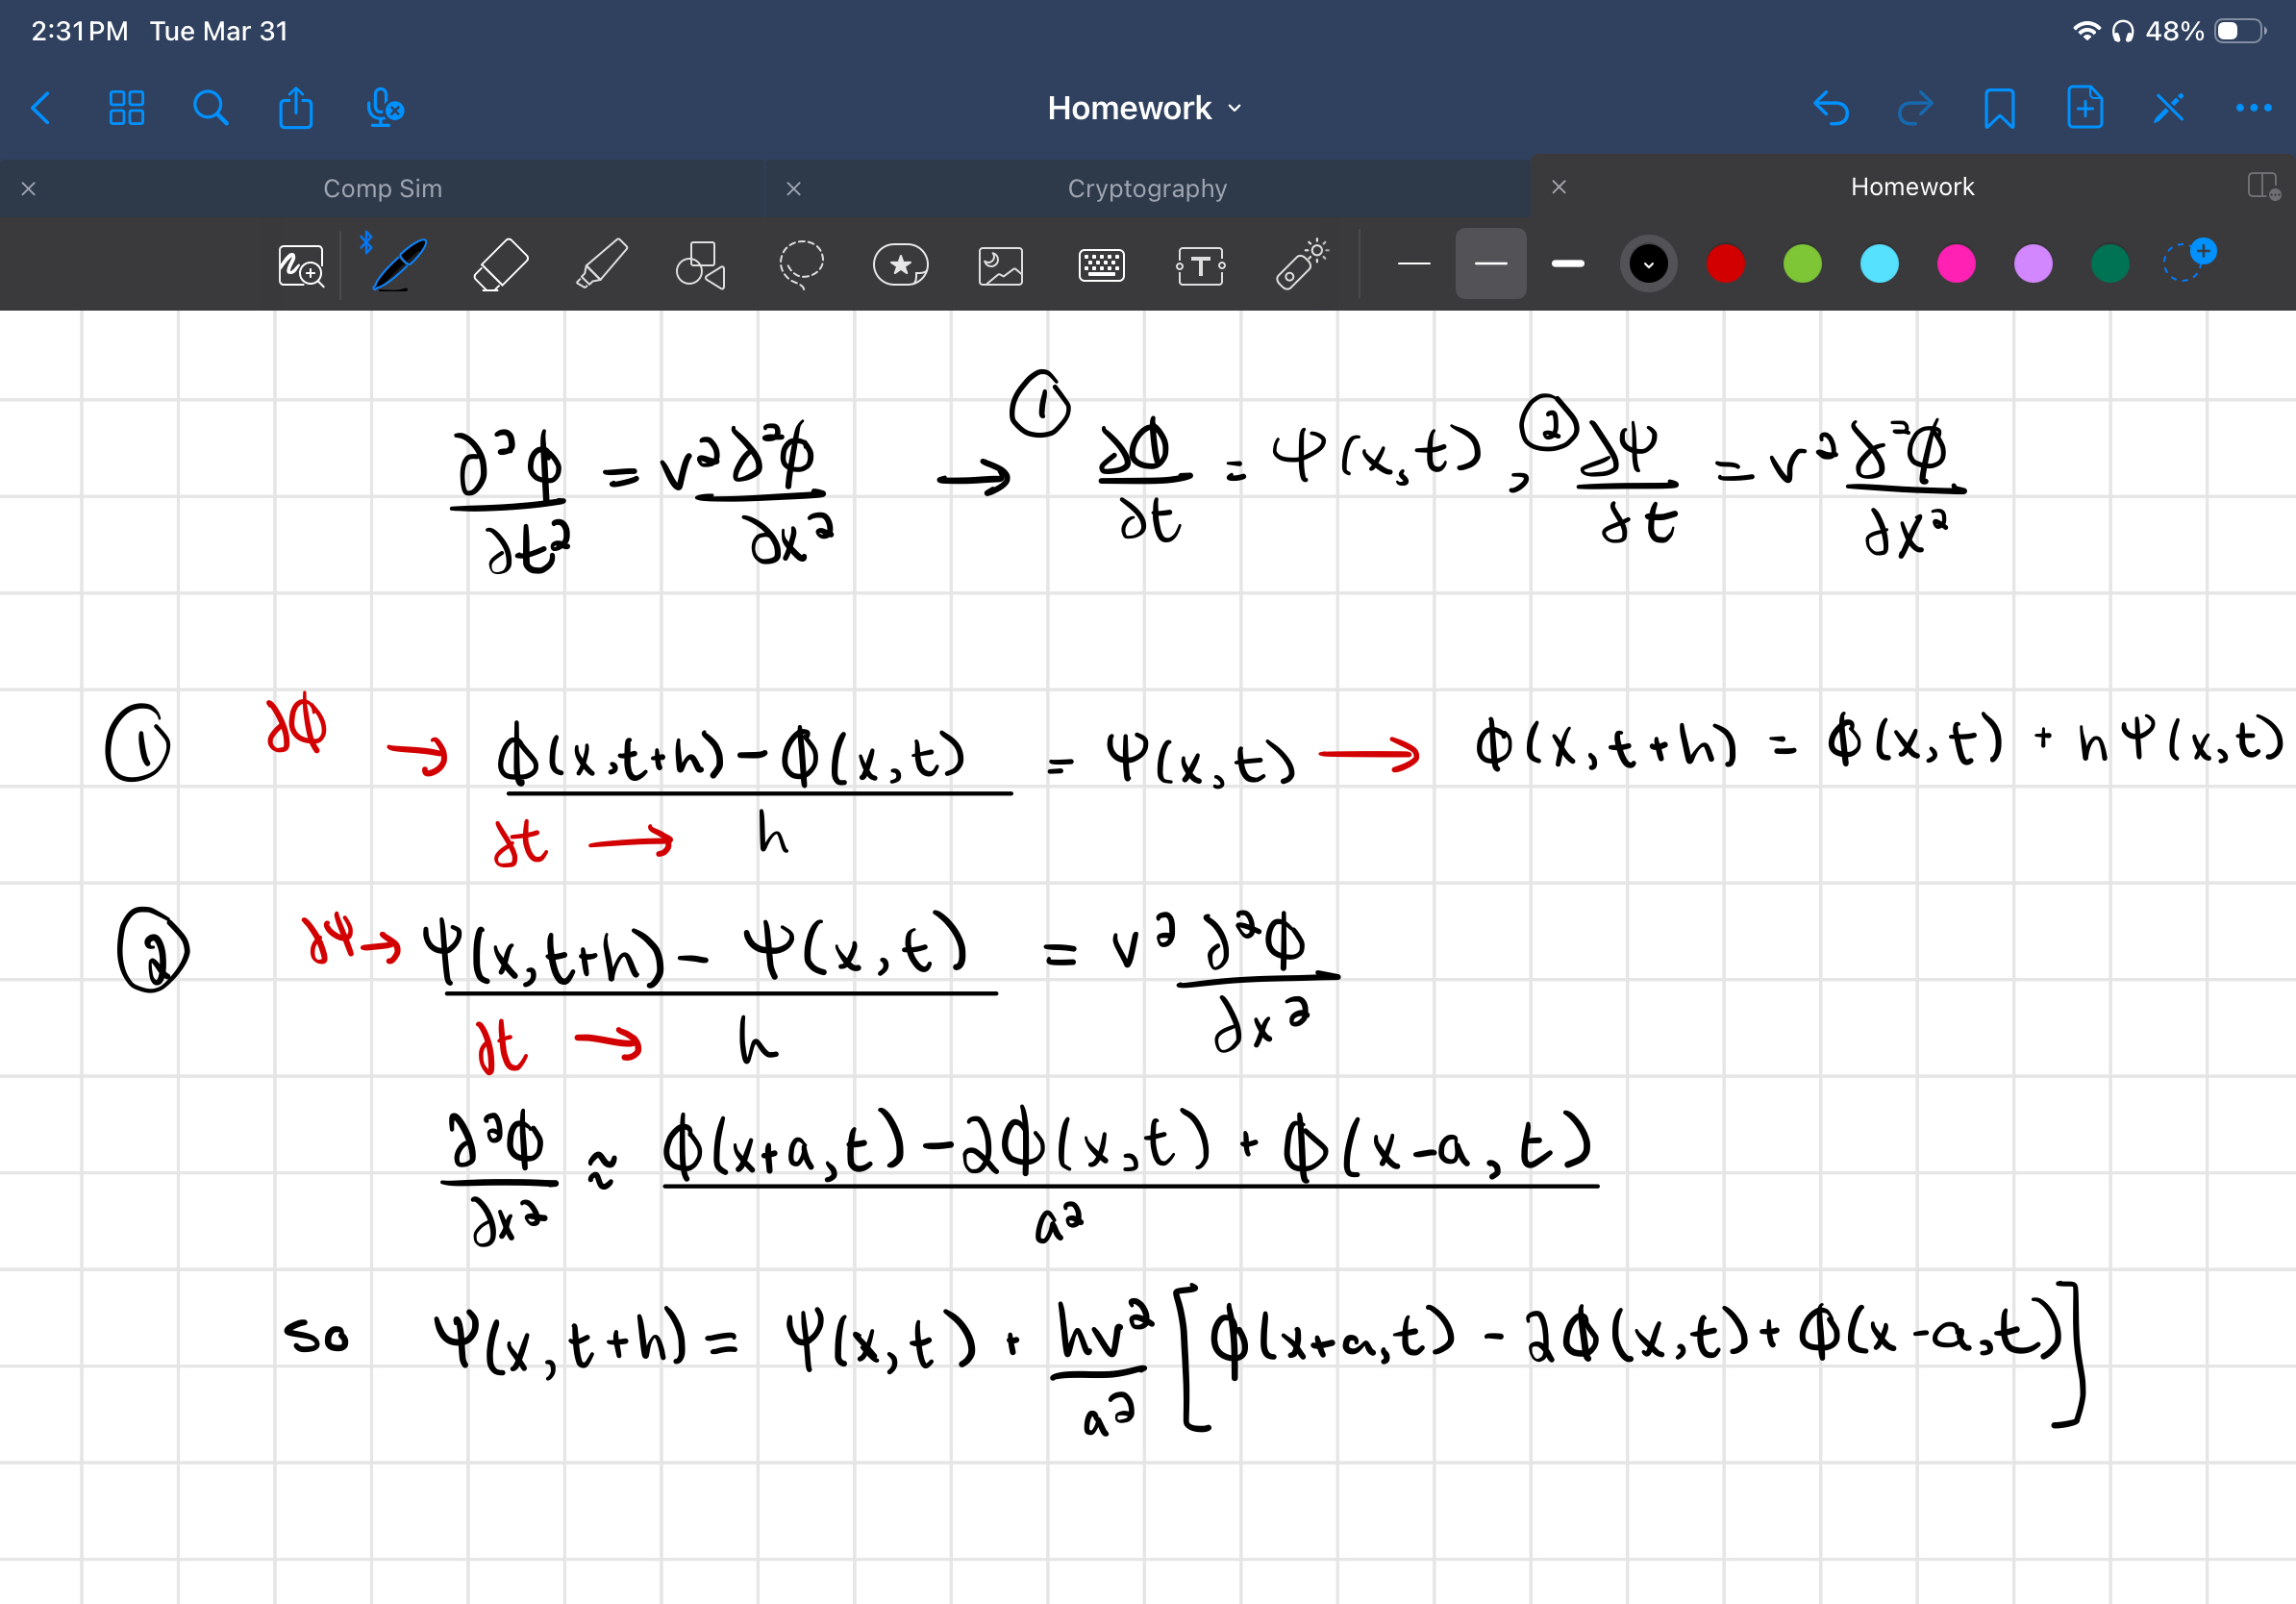

Question 4b

In [57]:
#function for solving the wave function with FTCS
def solve_wave(t_final):

    #initial conditions setup
    v = 100.0
    L = 1.0
    d = 0.1
    C = 1.0
    sigma = 0.3
    dx = 1e-2
    dt = 1e-6

    Nx = int(L / dx)
    Nt = int(t_final / dt)

    x = np.linspace(0, L, Nx+1)

    phi = np.zeros(Nx+1)
    psi = np.zeros(Nx+1)

    #set the initial conditions
    phi[:] = 0
    psi[:] = C * (x * (L - x) / L**2) * np.exp(-(x-d)**2 / (2 * sigma**2))

    for n in range(Nt):
        #create copies to avoid modifying
        phi_new = phi.copy()
        psi_new = psi.copy()

        for i in range(1, Nx):
            #FTCS equations
            phi_new[i] = phi[i] + dt *psi[i]
            psi_new[i] = psi[i] + dt * v**2 * (
                (phi[i+1] - 2*phi[i] + phi[i-1]) / dx**2
            )

        phi_new[0] = phi_new[Nx] = 0
        psi_new[0] = psi_new[Nx] = 0
        #set initial variables to new arrays
        phi = phi_new
        psi = psi_new

    return x, phi, psi

Question 4c

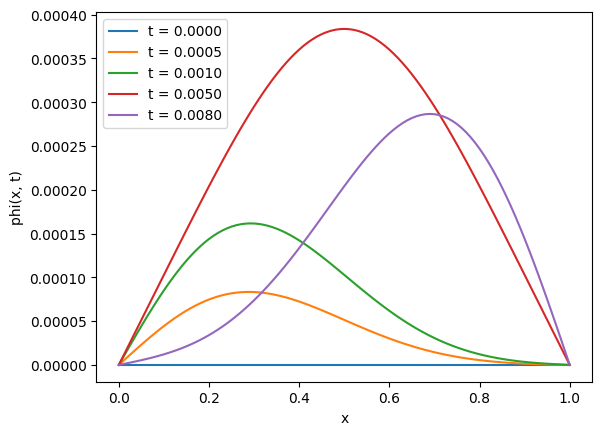

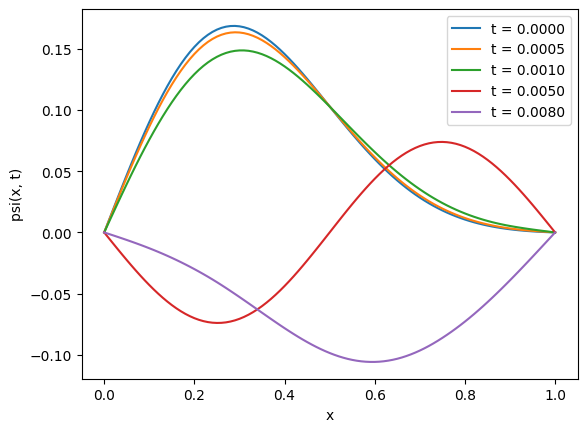

In [58]:
#times to measure
t_arr = [0, 5e-4, 1e-3, 5e-3, 8e-3]

#solve for each time (phi)
for t in t_arr:
    x, phi, psi = solve_wave(t)
    #plot result
    plt.plot(x, phi, label=f"t = {t:.4f}")

plt.legend()
plt.xlabel("x")
plt.ylabel("phi(x, t)")
plt.show()

#solve for each time (psi)
for t in t_arr:
    x, phi, psi = solve_wave(t)
    #plot result
    plt.plot(x, psi, label=f"t = {t:.4f}")

plt.legend()
plt.xlabel("x")
plt.ylabel("psi(x, t)")
plt.show()

Question 4d

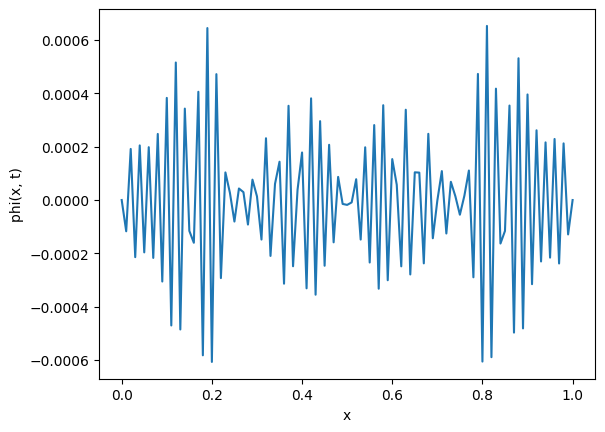

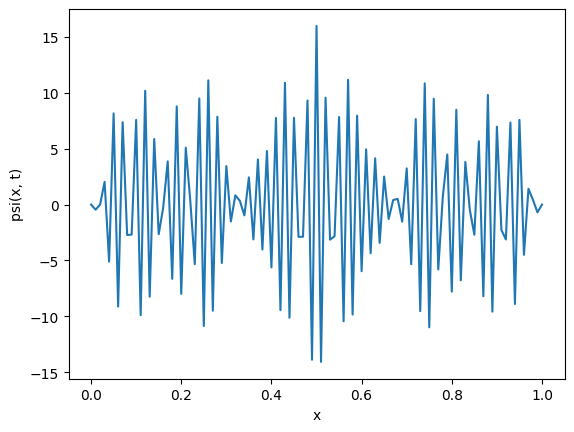

In [59]:
#large t value
t_new = 1e-1

#solve and plot result
x, phi, psi = solve_wave(t_new)

plt.plot(x, phi)
plt.xlabel("x")
plt.ylabel("phi(x, t)")
plt.show()

plt.plot(x, psi)
plt.xlabel("x")
plt.ylabel("psi(x, t)")
plt.show()